# Figshare FoG Dataset - Exploratory Data Analysis

Complete EDA for Freezing of Gait detection including temporal analysis, sensor statistics, episode characteristics, and data quality assessment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load and Prepare Dataset

In [2]:
imu_path = Path('../../Datasets/Figshare a public dataset/2 - IMU')
files = sorted(imu_path.glob('SUB*.txt'))

dfs = []
for file in files:
    df_file = pd.read_csv(file, sep='\t', skiprows=1, 
                          names=['frame', 'time_s', 'acc_ml_g', 'acc_ap_g', 'acc_si_g',
                                'gyr_ml_deg_s', 'gyr_ap_deg_s', 'gyr_si_deg_s', 'freezing_flag'])
    
    name = file.stem
    parts = name.split('_')
    subject_id = int(parts[0].replace('SUB', ''))
    
    if 'standing' in parts[1].lower():
        continue
    
    session_id = int(parts[1])
    df_file['subject_id'] = subject_id
    df_file['session_id'] = session_id
    dfs.append(df_file)

df = pd.concat(dfs, ignore_index=True)
df['label'] = df['freezing_flag'].astype(int)
df = df.drop('freezing_flag', axis=1)

print(f"Total samples: {len(df):,}")
print(f"Subjects: {df['subject_id'].nunique()}")
print(f"Shape: {df.shape}")

Total samples: 1,090,560
Subjects: 35
Shape: (1090560, 11)


## 2. General Dataset Information

In [3]:
n_subjects = df['subject_id'].nunique()
n_samples = len(df)
trials_per_subject = df.groupby('subject_id')['session_id'].nunique()

print(f"Total samples: {n_samples:,}")
print(f"Number of subjects: {n_subjects}")
print(f"Trials per subject (mean ± std): {trials_per_subject.mean():.1f} ± {trials_per_subject.std():.1f}")
print(f"Trials per subject (min-max): {trials_per_subject.min()}-{trials_per_subject.max()}")

Total samples: 1,090,560
Number of subjects: 35
Trials per subject (mean ± std): 2.0 ± 0.9
Trials per subject (min-max): 1-3


## 3. Class Balance Analysis

In [4]:
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index() * 100

print(f"No Freeze: {label_counts[0]:,} ({label_pct[0]:.2f}%)")
print(f"Freeze: {label_counts[1]:,} ({label_pct[1]:.2f}%)")
print(f"Imbalance ratio: {label_counts[0] / label_counts[1]:.2f}:1")

fog_per_subject = df[df['label']==1].groupby('subject_id').size()
total_per_subject = df.groupby('subject_id').size()
fog_pct_per_subject = (fog_per_subject / total_per_subject * 100).fillna(0)

print(f"\nFoG % per subject (mean ± std): {fog_pct_per_subject.mean():.2f}% ± {fog_pct_per_subject.std():.2f}%")

No Freeze: 884,226 (81.08%)
Freeze: 206,334 (18.92%)
Imbalance ratio: 4.29:1

FoG % per subject (mean ± std): 20.93% ± 31.09%


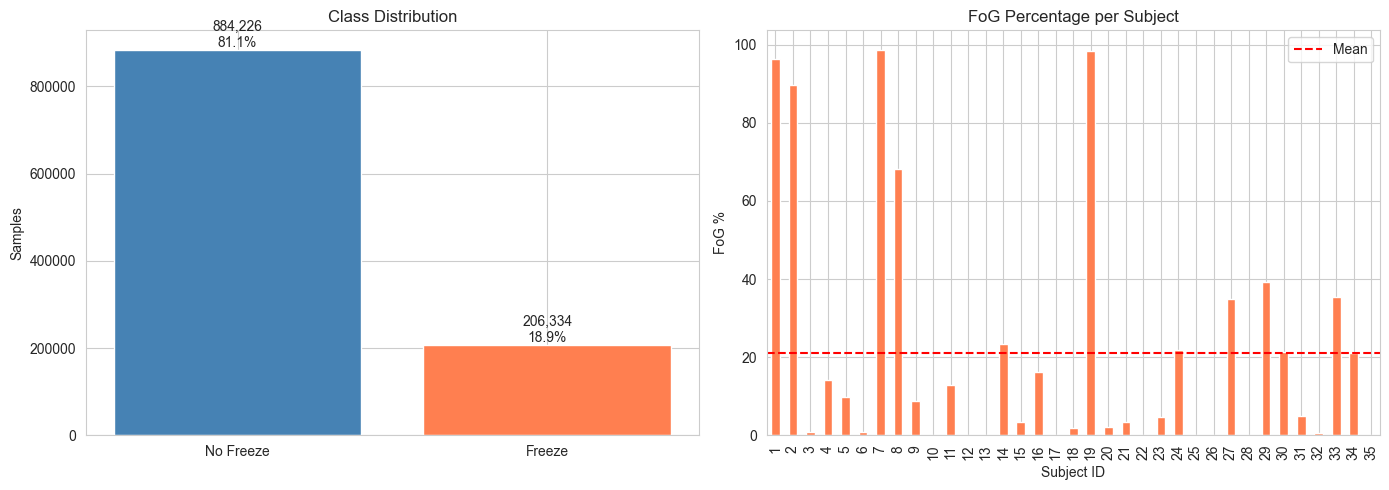

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['No Freeze', 'Freeze'], label_counts.values, color=['steelblue', 'coral'])
axes[0].set_ylabel('Samples')
axes[0].set_title('Class Distribution')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v, f'{v:,}\n{label_pct.values[i]:.1f}%', ha='center', va='bottom')

fog_pct_per_subject.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Subject ID')
axes[1].set_ylabel('FoG %')
axes[1].set_title('FoG Percentage per Subject')
axes[1].axhline(fog_pct_per_subject.mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Temporal Characteristics

In [6]:
# Sampling rate
sample = df[df['subject_id'] == df['subject_id'].iloc[0]].head(100)
time_diffs = np.diff(sample['time_s'].values)
sampling_rate = 1.0 / np.mean(time_diffs)

# Total recording duration
total_duration = df.groupby(['subject_id', 'session_id'])['time_s'].apply(lambda x: x.max() - x.min()).sum()

# FoG episodes
df['fog_change'] = df.groupby(['subject_id', 'session_id'])['label'].diff().fillna(0)
df['episode_id'] = (df['fog_change'] == 1).cumsum()
fog_episodes = df[df['label'] == 1].groupby('episode_id').agg(
    duration=('time_s', lambda x: x.max() - x.min()),
    subject=('subject_id', 'first'),
    session=('session_id', 'first')
).reset_index()

# Episodes per subject
episodes_per_subject = fog_episodes.groupby('subject').size()

print(f"Sampling rate: {sampling_rate:.2f} Hz")
print(f"Total recording duration: {total_duration/60:.2f} minutes")
print(f"Number of FoG episodes: {len(fog_episodes)}")
print(f"FoG episode duration (mean ± std): {fog_episodes['duration'].mean():.2f}s ± {fog_episodes['duration'].std():.2f}s")
print(f"FoG episode duration (min-max): {fog_episodes['duration'].min():.2f}s - {fog_episodes['duration'].max():.2f}s")
print(f"FoG episodes per subject (mean ± std): {episodes_per_subject.mean():.1f} ± {episodes_per_subject.std():.1f}")

Sampling rate: 128.00 Hz
Total recording duration: 141.99 minutes
Number of FoG episodes: 168
FoG episode duration (mean ± std): 9.41s ± 20.83s
FoG episode duration (min-max): 0.48s - 119.99s
FoG episodes per subject (mean ± std): 6.5 ± 6.8


## 5. Sensor Data Analysis

In [7]:
sensor_cols = ['acc_ml_g', 'acc_ap_g', 'acc_si_g', 'gyr_ml_deg_s', 'gyr_ap_deg_s', 'gyr_si_deg_s']

print("Overall statistics:")
print(df[sensor_cols].describe())

print("\nNo Freeze statistics:")
print(df[df['label']==0][sensor_cols].describe().loc[['mean', 'std']])

print("\nFreeze statistics:")
print(df[df['label']==1][sensor_cols].describe().loc[['mean', 'std']])

Overall statistics:
           acc_ml_g      acc_ap_g      acc_si_g  gyr_ml_deg_s  gyr_ap_deg_s  \
count  1.090560e+06  1.090560e+06  1.090560e+06  1.090560e+06  1.090560e+06   
mean   3.059837e-02 -2.496601e-01  9.773827e-01 -3.760616e+00  7.367288e-01   
std    5.645352e-01  4.178074e-01  3.297816e-01  3.501213e+01  4.133092e+01   
min   -8.561559e+00 -8.761489e+00 -7.205222e+00 -8.328335e+02 -3.372607e+02   
25%   -1.045563e-01 -3.298631e-01  9.208678e-01 -1.093880e+01 -1.319441e+01   
50%    2.864193e-02 -2.190791e-01  9.762873e-01  7.689217e-02  9.196744e-01   
75%    1.659377e-01 -1.123686e-01  1.038256e+00  9.165269e+00  1.426378e+01   
max    8.562497e+00  8.078460e+00  8.092385e+00  8.057459e+02  6.572037e+02   

       gyr_si_deg_s  
count  1.090560e+06  
mean  -1.570570e+00  
std    1.289649e+02  
min   -1.039652e+03  
25%   -2.517524e+01  
50%   -1.112511e+00  
75%    2.303421e+01  
max    1.149803e+03  

No Freeze statistics:
      acc_ml_g  acc_ap_g  acc_si_g  gyr_ml_deg_

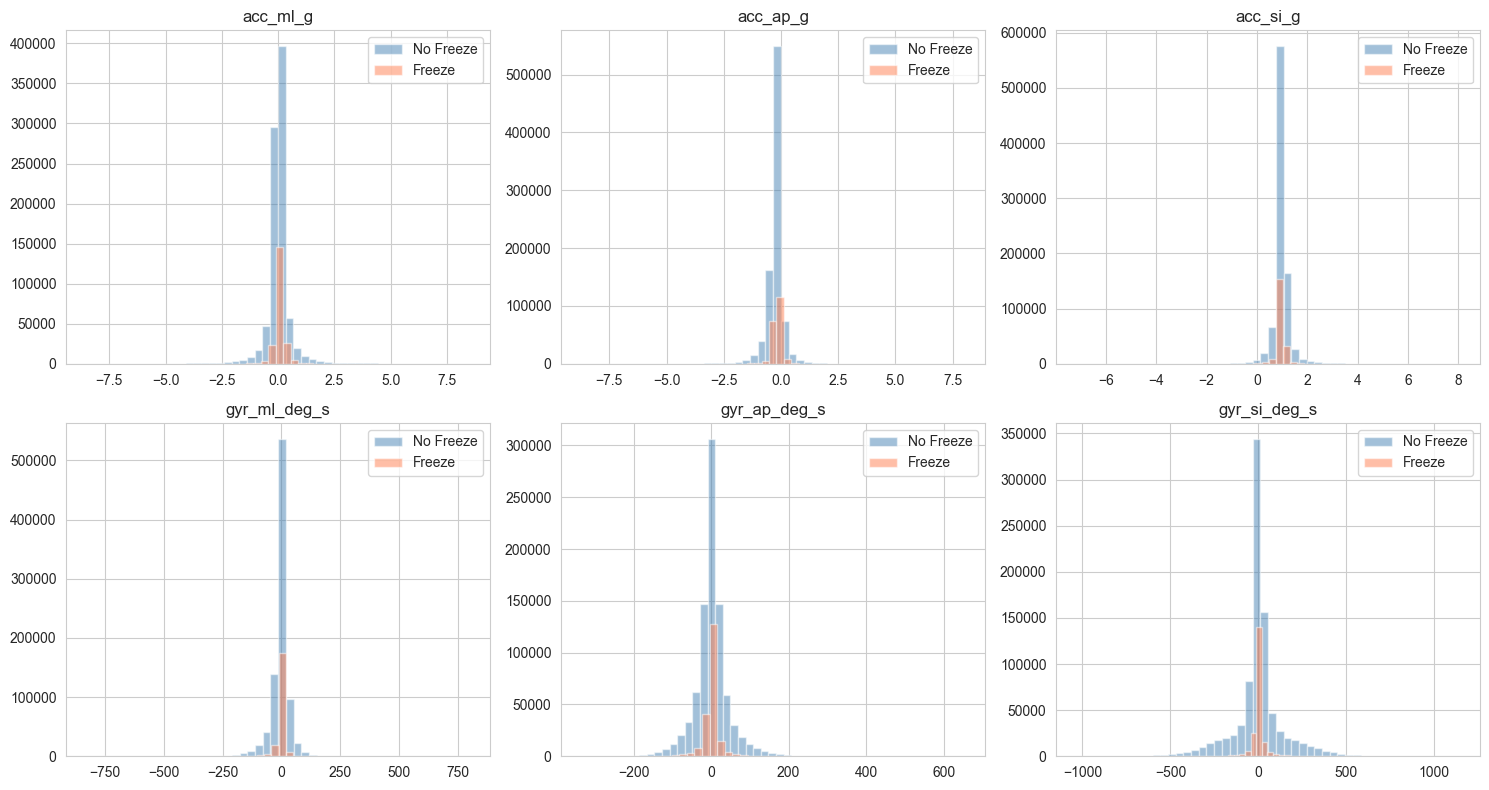

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(sensor_cols):
    df[df['label']==0][col].hist(bins=50, alpha=0.5, label='No Freeze', ax=axes[idx], color='steelblue')
    df[df['label']==1][col].hist(bins=50, alpha=0.5, label='Freeze', ax=axes[idx], color='coral')
    axes[idx].set_title(col)
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 6. FoG Episode Analysis

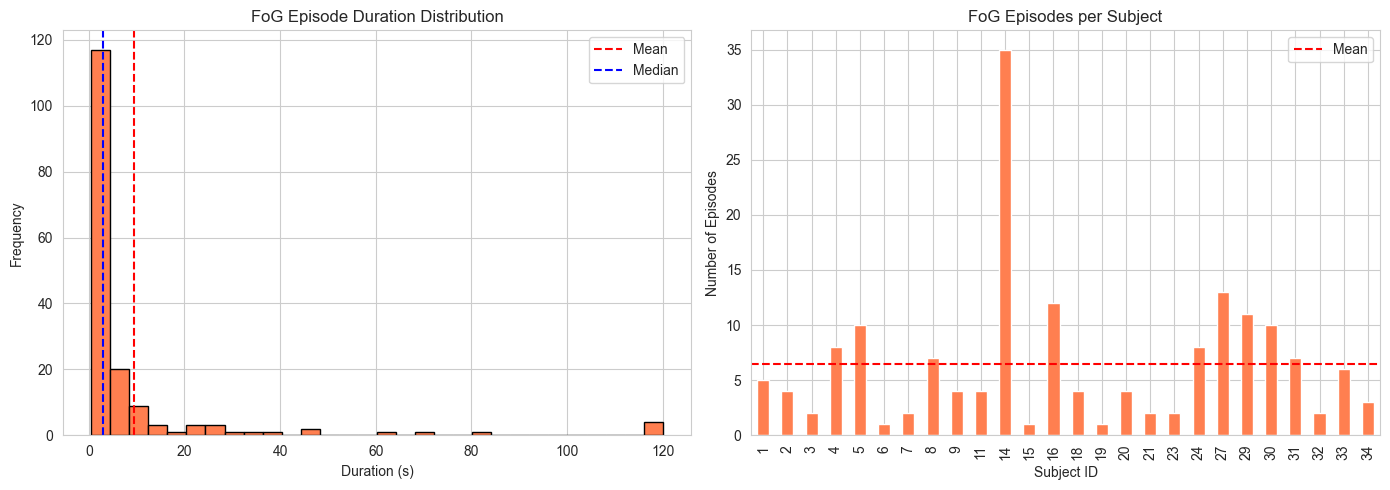

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram
axes[0].hist(fog_episodes['duration'], bins=30, color='coral', edgecolor='black')
axes[0].axvline(fog_episodes['duration'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(fog_episodes['duration'].median(), color='blue', linestyle='--', label='Median')
axes[0].set_xlabel('Duration (s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('FoG Episode Duration Distribution')
axes[0].legend()

# Episodes per subject
episodes_per_subject.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Subject ID')
axes[1].set_ylabel('Number of Episodes')
axes[1].set_title('FoG Episodes per Subject')
axes[1].axhline(episodes_per_subject.mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Transitions
transitions = (df['fog_change'].abs() > 0).sum()
fog_starts = (df['fog_change'] == 1).sum()
fog_ends = (df['fog_change'] == -1).sum()

print(f"Total transitions: {transitions}")
print(f"FoG starts: {fog_starts}")
print(f"FoG ends: {fog_ends}")

Total transitions: 326
FoG starts: 168
FoG ends: 158


## 7. Sensor Correlations

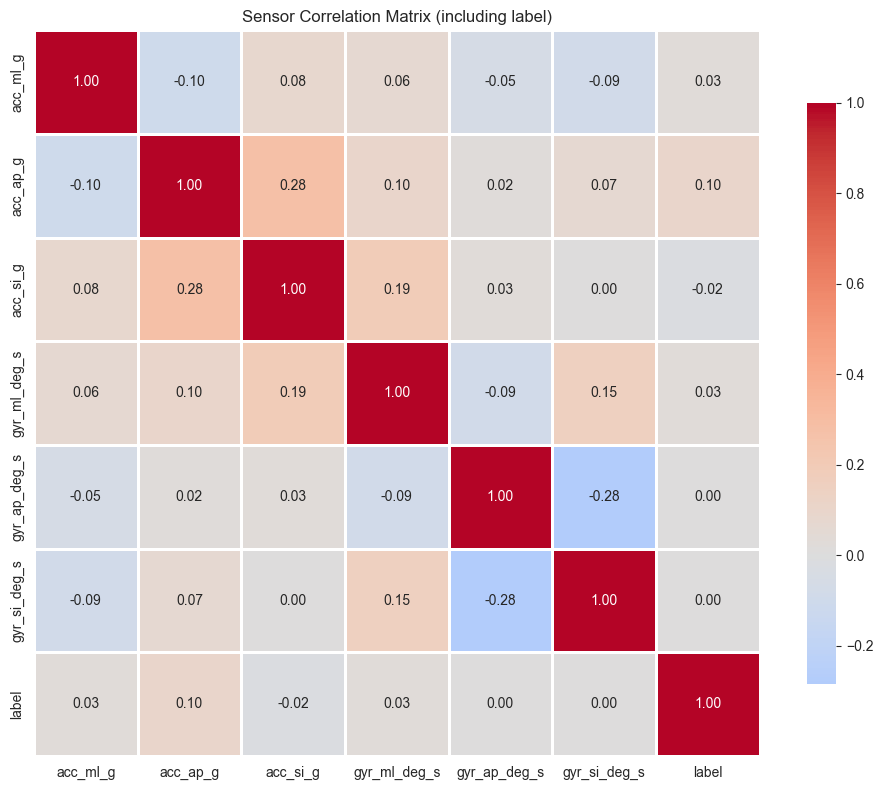

In [11]:
corr_cols = sensor_cols + ['label']
correlation = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Sensor Correlation Matrix (including label)')
plt.tight_layout()
plt.show()

## 8. Variability Analysis

In [12]:
# Inter-subject variability
inter_subject = df.groupby('subject_id')[sensor_cols].std().mean(axis=1)

# Intra-subject variability
intra_subject = df.groupby(['subject_id', 'session_id'])[sensor_cols].std().groupby('subject_id').mean().mean(axis=1)

print(f"Inter-subject variability (mean): {inter_subject.mean():.4f}")
print(f"Intra-subject variability (mean): {intra_subject.mean():.4f}")

# Consistency of FoG patterns
fog_consistency = fog_episodes.groupby('subject')['duration'].std().fillna(0)
print(f"\nFoG duration consistency (lower=more consistent): {fog_consistency.mean():.2f}")

Inter-subject variability (mean): 29.3558
Intra-subject variability (mean): 29.1156

FoG duration consistency (lower=more consistent): 8.40


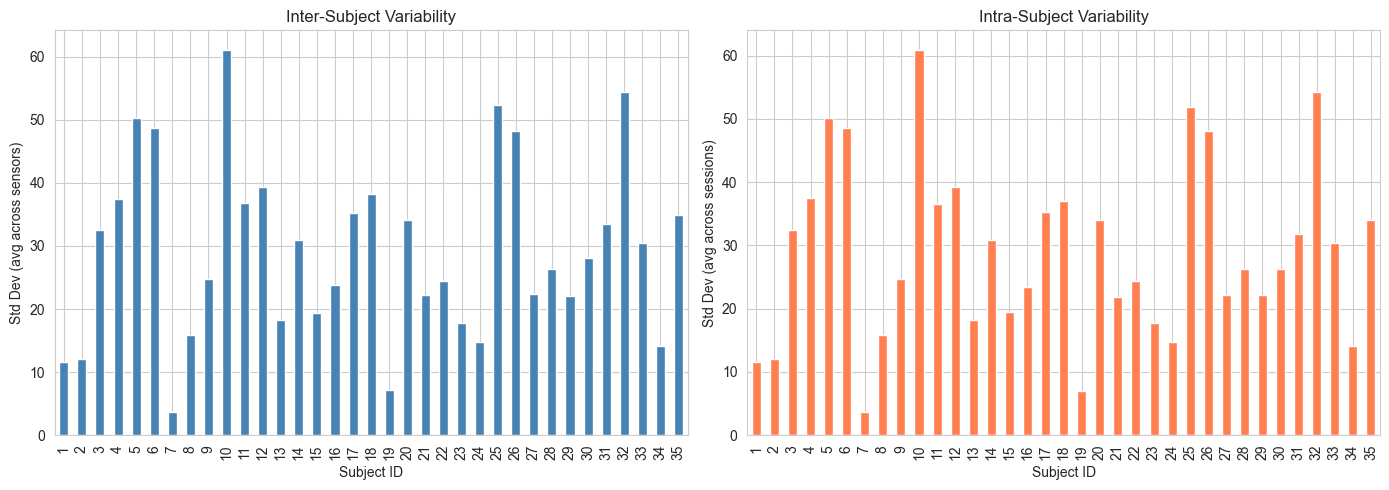

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

inter_subject.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Std Dev (avg across sensors)')
axes[0].set_title('Inter-Subject Variability')

intra_subject.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Subject ID')
axes[1].set_ylabel('Std Dev (avg across sessions)')
axes[1].set_title('Intra-Subject Variability')

plt.tight_layout()
plt.show()

## 9. Data Quality Assessment

In [14]:
# Missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

# Outliers (using IQR method)
Q1 = df[sensor_cols].quantile(0.25)
Q3 = df[sensor_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[sensor_cols] < (Q1 - 3*IQR)) | (df[sensor_cols] > (Q3 + 3*IQR))).sum()

print(f"\nOutliers (3*IQR):")
print(outliers)

# Discontinuities
time_jumps = df.groupby(['subject_id', 'session_id'])['time_s'].apply(
    lambda x: (np.diff(x) > 0.1).sum()
)
print(f"\nTime discontinuities (>0.1s): {time_jumps.sum()}")

Missing values:
No missing values

Outliers (3*IQR):
acc_ml_g         60804
acc_ap_g         54383
acc_si_g        100939
gyr_ml_deg_s     65275
gyr_ap_deg_s     52338
gyr_si_deg_s    162263
dtype: int64

Time discontinuities (>0.1s): 0


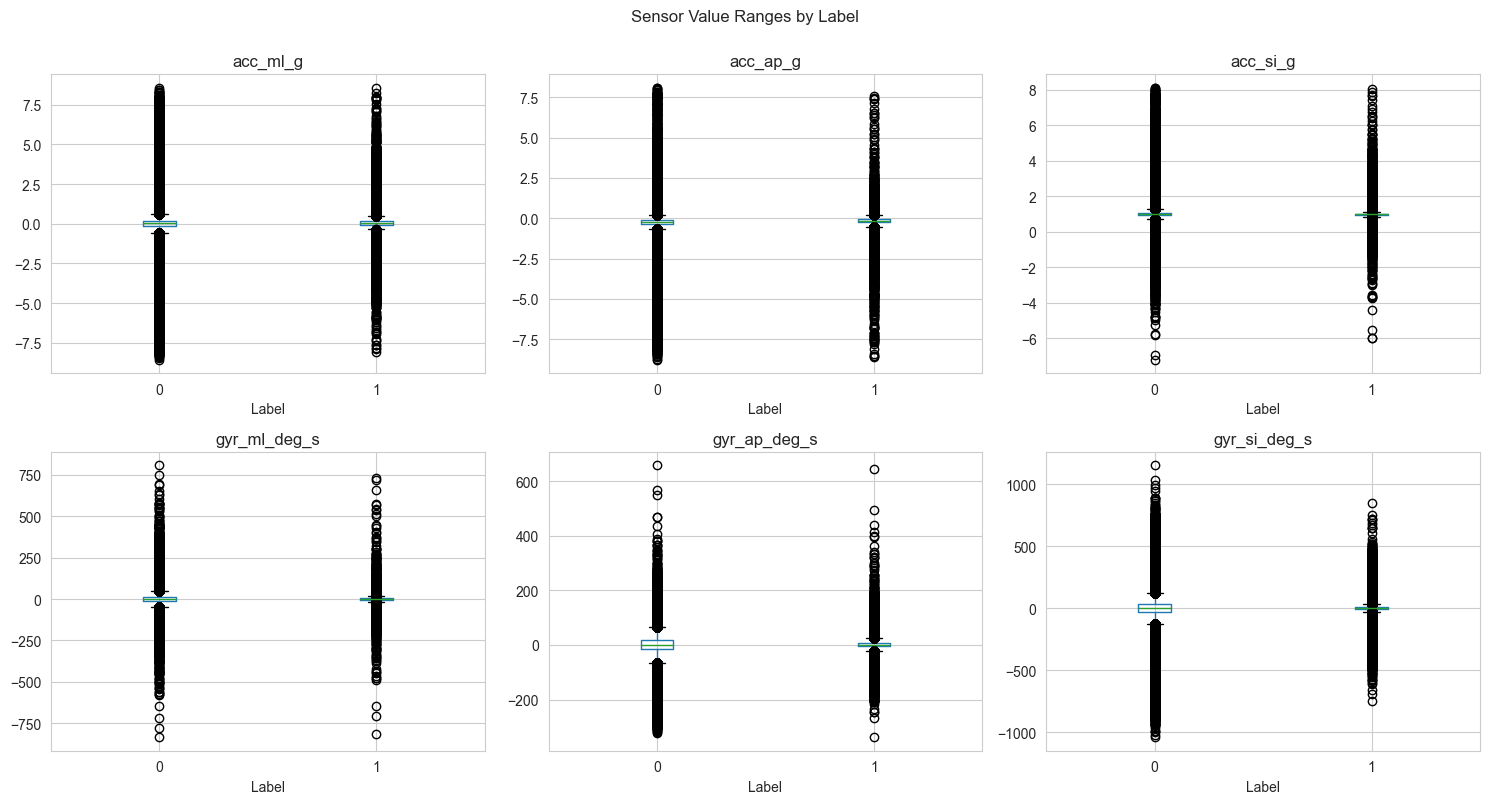

In [15]:
# Value ranges
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(sensor_cols):
    df.boxplot(column=col, by='label', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Label')

plt.suptitle('Sensor Value Ranges by Label', y=1.00)
plt.tight_layout()
plt.show()

## 10. Key Visualizations

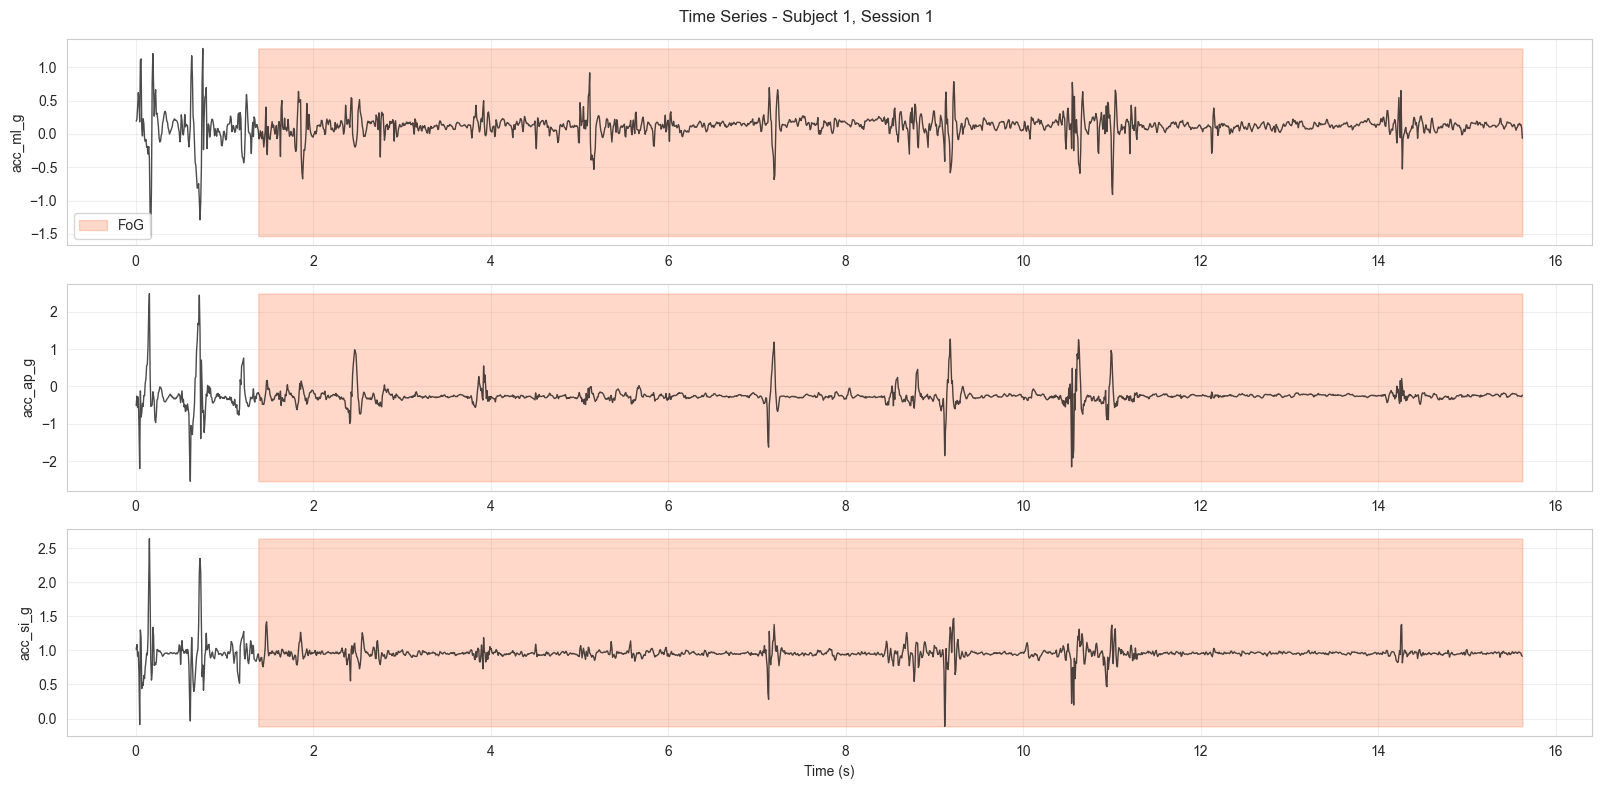

In [16]:
# Time series with episodes marked
sample_subject = df['subject_id'].iloc[0]
sample_session = df[df['subject_id']==sample_subject]['session_id'].iloc[0]
sample_data = df[(df['subject_id']==sample_subject) & (df['session_id']==sample_session)].iloc[:2000]

fig, axes = plt.subplots(3, 1, figsize=(16, 8))

for idx, col in enumerate(['acc_ml_g', 'acc_ap_g', 'acc_si_g']):
    axes[idx].plot(sample_data['time_s'], sample_data[col], linewidth=1, color='black', alpha=0.7)
    
    fog_mask = sample_data['label'] == 1
    if fog_mask.any():
        axes[idx].fill_between(sample_data['time_s'], 
                              sample_data[col].min(), sample_data[col].max(),
                              where=fog_mask, alpha=0.3, color='coral', label='FoG')
    
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].legend()

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Time Series - Subject {sample_subject}, Session {sample_session}')
plt.tight_layout()
plt.show()

## 11. Export Dataset

In [17]:
# Clean temporary columns
df_export = df.drop(['fog_change', 'episode_id'], axis=1, errors='ignore')

output_path = '../../outputs/datasets_csv/figshare_complete_dataset.csv'
df_export.to_csv(output_path, index=False)

print(f"Dataset saved: {output_path}")
print(f"Samples: {len(df_export):,}")
print(f"Columns: {list(df_export.columns)}")

Dataset saved: ../../outputs/datasets_csv/figshare_complete_dataset.csv
Samples: 1,090,560
Columns: ['frame', 'time_s', 'acc_ml_g', 'acc_ap_g', 'acc_si_g', 'gyr_ml_deg_s', 'gyr_ap_deg_s', 'gyr_si_deg_s', 'subject_id', 'session_id', 'label']
